In [1]:
import torch
from torch import nn
from torch.nn import BatchNorm1d
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import os
import json
import random
import pkbar
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import datetime
import shutil
import time
import numpy as np


from sklearn.preprocessing import MinMaxScaler
from utils.createLoader import createLoaders

In [2]:
### Constants
DATA_PATH = 'data/cmod_clean_200ms.csv';
CONFIG_PATH = "class_TI_columnsdropped.json"

####


pd.set_option("display.max_columns", None);
config = None
### Config
with open(CONFIG_PATH, 'r', encoding = 'utf-8') as file: 
    config = json.load(file)

the shape of datasetX is torch.Size([518788, 40])
the shape of datasetY is torch.Size([518788])


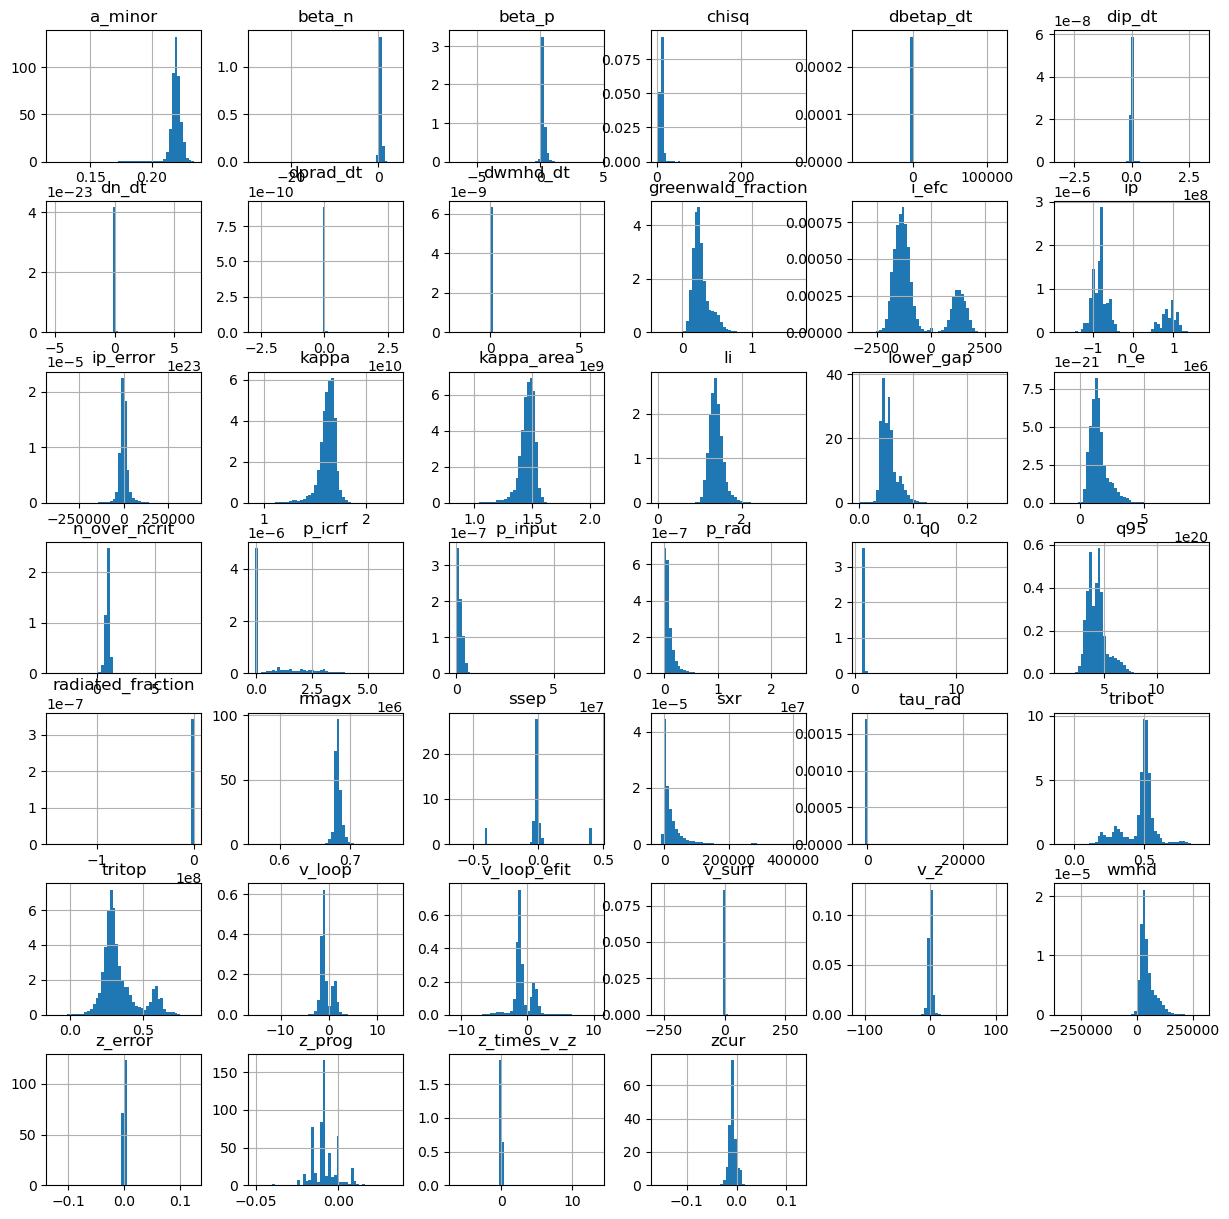

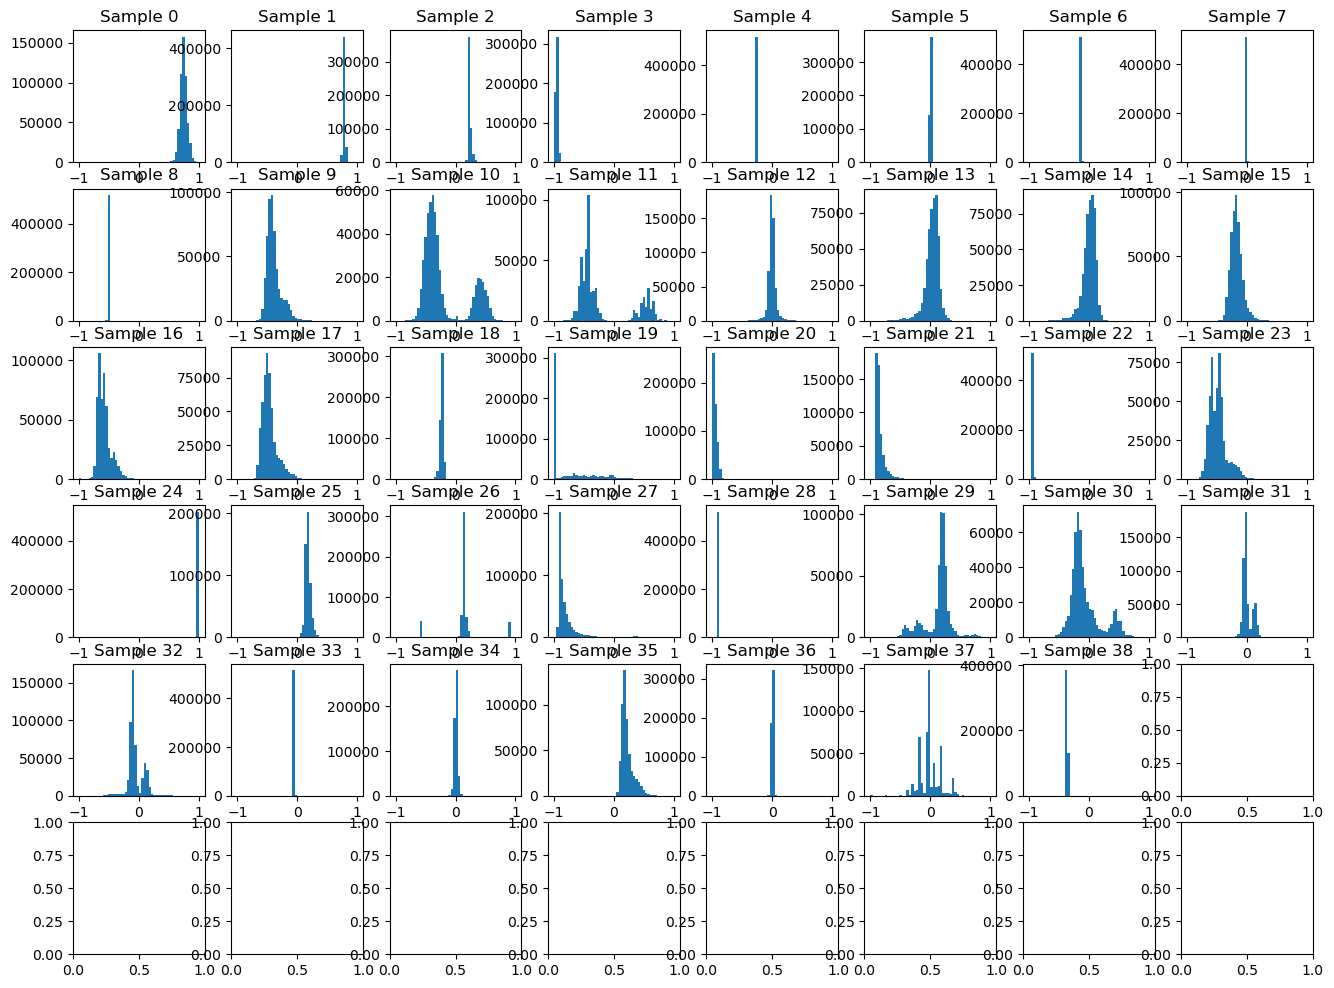

In [3]:
dataset =pd.read_csv(DATA_PATH,sep=',',index_col=None)

train_loader, test_loader, val_loader = createLoaders(config, dataset=dataset)

In [4]:
# X, y = next(iter(class_ti_train))  # grab one batch

# fig, axes = plt.subplots(6, 8, figsize=(16, 12))
# axes = axes.ravel()  # flatten into 1D array

# columns_to_plot = np.arange(2, 40)

# for i in columns_to_plot:
#     data_to_plot = X[:, i].detach().cpu().numpy()
#     axes[i].hist(data_to_plot[i], bins=20)
#     axes[i].set_title(f"Sample {i}")

# print(X[:,].shape)

features to ignore because they're probably useless

```
time
dip_smoothed
dipprog_dt
dli_dt
ip_prog
p_lh
p_oh
qstar
upper_gap
```


In [5]:
class MLP(nn.Module):
    def __init__(self,input_shape,output_shape):
        super(MLP, self).__init__()

        self.init_layer = nn.Linear(input_shape,64)
        self.B0 = nn.BatchNorm1d(64)
        self.L1 = nn.Linear(64,256)
        self.B1 = nn.BatchNorm1d(256)
        self.L2 = nn.Linear(256,512)
        self.B2 = nn.BatchNorm1d(512)
        self.L3 = nn.Linear(512,256)
        self.B3 = nn.BatchNorm1d(256)
        self.L4 = nn.Linear(256,128)
        self.B4 = nn.BatchNorm1d(128)
        self.output = nn.Linear(128,output_shape)
        self.activation = nn.SELU()
        self.output_activation = nn.Sigmoid()
    def forward(self,x):

        x = self.activation(self.B0(self.init_layer(x))) # SELU(BNorm(Linear(x)))
        x = self.activation(self.B1(self.L1(x)))
        x = self.activation(self.B2(self.L2(x)))
        x = self.activation(self.B3(self.L3(x)))
        x = self.activation(self.B4(self.L4(x)))
        x = self.output_activation(self.output(x)) # Sigmoid is obvious choice here, constrain to probabalistic interval (0,1)

        return x

In [6]:
X_sample, y_sample = next(iter(train_loader))  # grab one batch

num_cols = X_sample.shape[1]

classifier = MLP(input_shape = num_cols,output_shape=1) # Singular output
print(classifier)

MLP(
  (init_layer): Linear(in_features=40, out_features=64, bias=True)
  (B0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L1): Linear(in_features=64, out_features=256, bias=True)
  (B1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L2): Linear(in_features=256, out_features=512, bias=True)
  (B2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L3): Linear(in_features=512, out_features=256, bias=True)
  (B3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (L4): Linear(in_features=256, out_features=128, bias=True)
  (B4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (activation): SELU()
  (output_activation): Sigmoid()
)


In [7]:
def trainer(config,train_loader,val_loader):
    # Setup random seed
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])
    torch.cuda.manual_seed(config['seed'])

    # Create experiment name
    exp_name = config['name']
    print(exp_name)

    # Create directory structure
    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder,exp_name)
    os.makedirs(output_path,exist_ok=True)

    with open(os.path.join(output_path,'config.json'),'w') as outfile:
        json.dump(config, outfile)


       # Load the dataset
    
    history = {'train_loss':[],'val_loss':[],'lr':[]}


    print("Training Size: {0}".format(len(train_loader.dataset)))
    print("Validation Size: {0}".format(len(val_loader.dataset)))

    # Create the model
    input_shape = num_cols
    output_shape = 1
    net = MLP(input_shape=input_shape,output_shape=output_shape)
    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters: ",t_params)
    device = torch.device('cuda')
    net.to('cuda')

    # Optimizer
    num_epochs=int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(list(filter(lambda p: p.requires_grad, net.parameters())), lr=lr)
    num_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=num_steps, last_epoch=-1,
                                                           eta_min=0)

    startEpoch = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')


    # Loss Function
    loss_function = nn.BCELoss()
    for epoch in range(startEpoch,num_epochs):

        kbar = pkbar.Kbar(target=len(train_loader), epoch=epoch, num_epochs=num_epochs, width=20, always_stateful=False)

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            input  = data[0].to('cuda').float()
            y = data[1].to('cuda').float()

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                y_hat = net(input)

            y_hat = y_hat.flatten()

            loss = loss_function(y_hat,y)
            train_acc = (torch.sum(torch.round(y_hat) == y)).item() / len(y)

            loss.backward()
            #torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.01,error_if_nonfinite=True)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * input.shape[0]
            kbar.update(i, values=[("loss", loss.item()),("train_acc",train_acc)])
            global_step += 1


        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['lr'].append(scheduler.get_last_lr()[0])


        ######################
        ## validation phase ##
        ######################
        if bool(config['run_val']):
            net.eval()
            val_loss = 0.0
            val_acc = 0.0
            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    input  = data[0].to('cuda').float()
                    y = data[1].to('cuda').float()
                    y_hat = net(input)
                    y_hat = y_hat.flatten()
                    
                    loss = loss_function(y_hat,y)

                    val_acc += (torch.sum(torch.round(y_hat) == y)).item() / len(y)
                    val_loss += loss

            val_loss = val_loss.cpu().numpy() / len(val_loader)
            val_acc /= len(val_loader)
            history['val_loss'].append(val_loss)

            kbar.add(1, values=[("val_loss", val_loss.item()),("val_acc",val_acc)])

            name_output_file = config['name']+'_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)

        else:
            kbar.add(1,values=[('val_loss',0.)])
            name_output_file = config['name']+'_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, running_loss / len(train_loader.dataset))

        filename = os.path.join(output_path, name_output_file)

        checkpoint={}
        checkpoint['net_state_dict'] = net.state_dict()
        checkpoint['optimizer'] = optimizer.state_dict()
        checkpoint['scheduler'] = scheduler.state_dict()
        checkpoint['epoch'] = epoch
        checkpoint['history'] = history
        checkpoint['global_step'] = global_step

        torch.save(checkpoint,filename)

        print('')

In [8]:
trainer(config = config,train_loader=train_loader,val_loader=val_loader)

basic_classifier
Training Size: 363152
Validation Size: 77818
Network Parameters:  317633
===========  Optimizer  ==================:
      LR: 0.0001
      num_epochs: 10

Epoch: 1/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.1598 - train_acc: 0.9632 - val_loss: 0.1077 - val_acc: 0.9737

Epoch: 2/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.1071 - train_acc: 0.9733 - val_loss: 0.1016 - val_acc: 0.9738

Epoch: 3/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.1025 - train_acc: 0.9737 - val_loss: 0.0990 - val_acc: 0.9742

Epoch: 4/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.0992 - train_acc: 0.9741 - val_loss: 0.0968 - val_acc: 0.9746

Epoch: 5/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.0963 - train_acc: 0.9745 - val_loss: 0.0947 - val_acc: 0.9751

Epoch: 6/10
2838/2838 [====================] - 9s 3ms/step - loss: 0.0934 - train_acc: 0.9748 - val_loss: 0.0930 - val_acc: 0.9754

Epoch: 7/10
2838/2838 [============

In [9]:
dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))
print(dicte.keys())

dict_keys(['net_state_dict', 'optimizer', 'scheduler', 'epoch', 'history', 'global_step'])


/tmp/ipykernel_755/4877196.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))


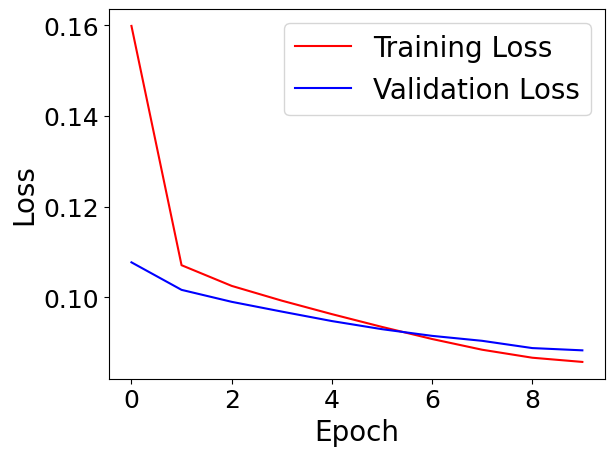

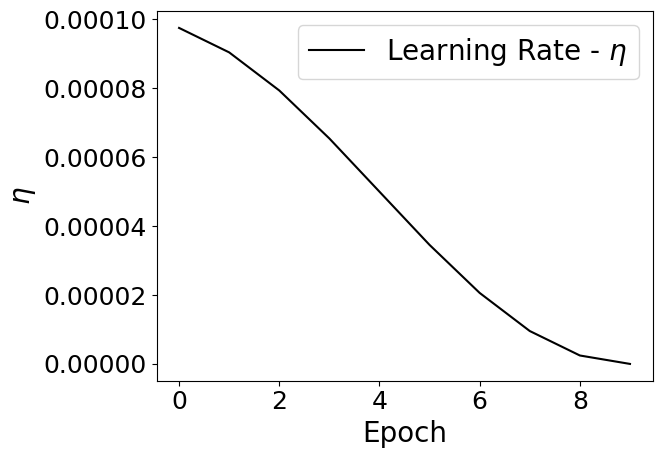

In [10]:
train_loss = dicte['history']['train_loss']
val_loss = dicte['history']['val_loss']
learning_rate = dicte['history']['lr']

plt.plot(train_loss,'r-',label="Training Loss")
plt.plot(val_loss,'b-',label='Validation Loss')
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel('Loss',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.show()

plt.plot(learning_rate,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel(r'$\eta$',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.show()

In [11]:
input_shape = num_cols
output_shape = config['model']['output_shape']
net = MLP(input_shape=input_shape,output_shape=output_shape)
t_params = sum(p.numel() for p in net.parameters())
print("Network Parameters: ",t_params)
device = torch.device('cuda')
net.to('cuda')

dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))
net.load_state_dict(dicte["net_state_dict"])

Network Parameters:  317633


/tmp/ipykernel_755/2744452832.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))


<All keys matched successfully>

In [12]:
net.eval() # Eval mode

predictions = []
y_true = []
kbar = pkbar.Kbar(target=len(test_loader), width=20, always_stateful=False)
for i,data in enumerate(test_loader):
    x = data[0].to('cuda').float()
    y_true.append(data[1].numpy())

    with torch.set_grad_enabled(False): # Same as with torch.no_grad():
        y_hat = net(x).detach().cpu().numpy()

    predictions.append(y_hat)

    kbar.update(i)

predictions = np.concatenate(predictions)
y_true = np.concatenate(y_true)

562/608 [=================>..] - ETA: 0s

AUC: 0.95


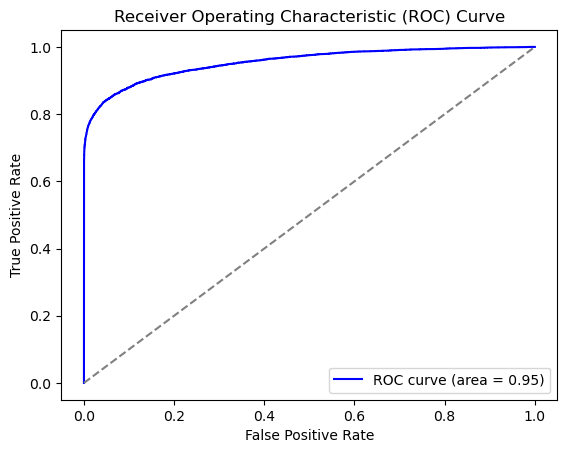

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, predictions)

# Calculate the AUC (Area Under the Curve)
auc = roc_auc_score(y_true, predictions)
print(f"AUC: {auc:.2f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
 [[71742    73]
 [ 1805  4198]]


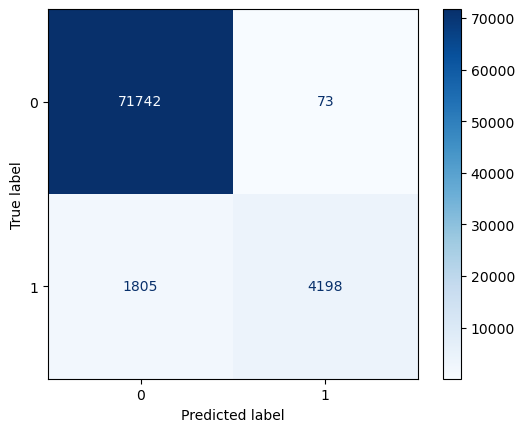

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

cm = confusion_matrix(y_true, predictions.round())
print("Confusion Matrix:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [15]:
print(classification_report(y_true,predictions.round()))

# Compute metrics
precision = precision_score(y_true, predictions.round())
recall = recall_score(y_true, predictions.round())
f1 = f1_score(y_true, predictions.round())

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     71815
           1       0.98      0.70      0.82      6003

    accuracy                           0.98     77818
   macro avg       0.98      0.85      0.90     77818
weighted avg       0.98      0.98      0.97     77818

Precision: 0.9829079840786701
Recall: 0.6993170081625854
F1 Score: 0.8172084874440335
